In [ ]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


drive.mount('/content/drive')

df = pd.read_csv('/creditcard.csv')

conteo = df['Class'].value_counts().sort_index()
porcentaje = df['Class'].value_counts(normalize=True).sort_index() * 100

print("-" * 50)
print(f"Total de transacciones: {len(df):,}")
print(f"Transacciones Legítimas (0): {conteo[0]:,} ({porcentaje[0]:.2f}%)")
print(f"Transacciones Fraudulentas (1): {conteo[1]:,} ({porcentaje[1]:.2f}%)")
print(f"Ratio Fraude/Total: 1 de cada {int(len(df)/conteo[1])} transacciones")
print("-" * 50)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análisis de Fraude en Transacciones de Crédito', fontsize=16, fontweight='bold', y=1.02)

colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(['Legítimas', 'Fraudulentas'], conteo.values, color=colors, edgecolor='black', linewidth=1.5, alpha=0.85)

for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[0].set_ylabel('Cantidad de Transacciones', fontsize=12, fontweight='bold')
axes[0].set_title('Conteo Absoluto (Escala Lineal)', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_ylim(0, max(conteo.values) * 1.1)


wedges, texts, autotexts = axes[1].pie(conteo.values,
                                         labels=['Legítimas', 'Fraudulentas'],
                                         autopct='%1.2f%%',
                                         colors=colors,
                                         startangle=90,
                                         explode=(0, 0.1),
                                         shadow=True,
                                         textprops={'fontsize': 11, 'fontweight': 'bold'})


for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

axes[1].set_title('Distribución Porcentual', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


fig2, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(['Legítimas', 'Fraudulentas'], conteo.values, color=colors, edgecolor='black', linewidth=1.5, alpha=0.85)


for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}\n({porcentaje.values[i]:.2f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Cantidad de Transacciones (Escala Logarítmica)', fontsize=12, fontweight='bold')
ax.set_title('Distribución de Fraude - Escala Logarítmica', fontsize=14, fontweight='bold')
ax.set_yscale('log')
ax.grid(axis='y', alpha=0.3, linestyle='--', which='both')

plt.tight_layout()
plt.show()


print("\n estadisticas:")
print(f"   • Desbalance de clases: {conteo[0]/conteo[1]:.1f}x más transacciones legítimas")
print(f"   • Monto total de transacciones legítimas: ${df[df['Class']==0]['Amount'].sum():,.2f}")
print(f"   • Monto total de transacciones fraudulentas: ${df[df['Class']==1]['Amount'].sum():,.2f}")
print(f"   • Monto promedio (legítimas): ${df[df['Class']==0]['Amount'].mean():.2f}")
print(f"   • Monto promedio (fraudulentas): ${df[df['Class']==1]['Amount'].mean():.2f}")

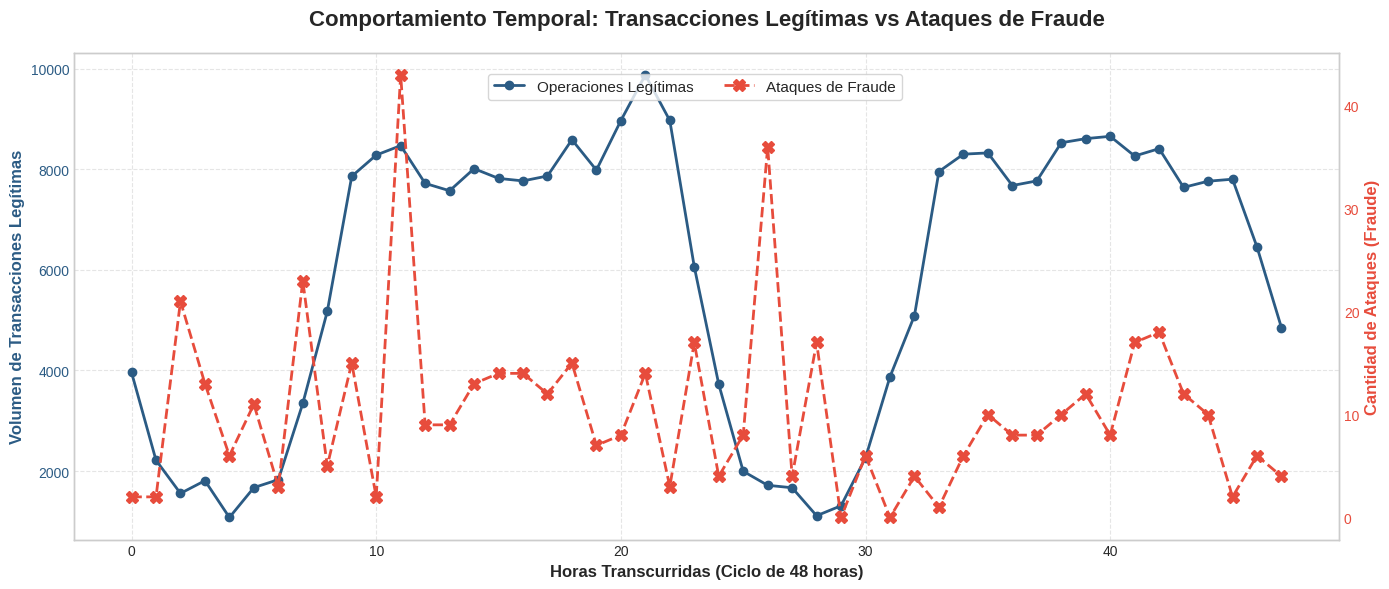

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df['Hour'] = (df['Time'] / 3600).astype(int)


resumen_hora = df.groupby('Hour')['Class'].value_counts().unstack().fillna(0)
resumen_hora.columns = ['Legítimas', 'Fraude']


plt.style.use('seaborn-v0_8-whitegrid')
fig, ax1 = plt.subplots(figsize=(14, 6))


ax1.plot(resumen_hora.index, resumen_hora['Legítimas'], color='#2b5b84',
         marker='o', markersize=6, label='Operaciones Legítimas', linewidth=2)
ax1.set_xlabel('Horas Transcurridas (Ciclo de 48 horas)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Volumen de Transacciones Legítimas', fontsize=12, color='#2b5b84', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#2b5b84')


ax2 = ax1.twinx()
ax2.plot(resumen_hora.index, resumen_hora['Fraude'], color='#e74c3c',
         marker='X', markersize=9, linestyle='--', label='Ataques de Fraude', linewidth=2)
ax2.set_ylabel('Cantidad de Ataques (Fraude)', fontsize=12, color='#e74c3c', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#e74c3c')


plt.title('Comportamiento Temporal: Transacciones Legítimas vs Ataques de Fraude',
          fontsize=16, fontweight='bold', pad=20)
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.88), ncol=2, frameon=True, fontsize=11)


ax1.grid(True, linestyle='--', alpha=0.5)
ax2.grid(False)

plt.tight_layout()
plt.show()

In [ ]:

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


X = df.drop(['Class', 'Time'], axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"   -> Fraudes antes de SMOTE: {sum(y_train == 1)}")
print(f"   -> Fraudes DESPUÉS de SMOTE: {sum(y_train_smote == 1)}" )



rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_model.fit(X_train_smote, y_train_smote)


y_pred_rf = rf_model.predict(X_test)


print("REPORTE DE RENDIMIENTO: RANDOM FOREST")
print(classification_report(y_test, y_pred_rf, target_names=['Legítima (0)', 'Fraude (1)']))


fig, ax = plt.subplots(figsize=(6, 4))
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf), display_labels=['Legítima', 'Fraude'])
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title('Matriz de Confusión: Random Forest', fontsize=14, fontweight='bold', pad=15)
plt.grid(False)
plt.show()

   -> Fraudes antes de SMOTE: 394
   -> Fraudes DESPUÉS de SMOTE: 227451


MLP
              precision    recall  f1-score   support

Legítima (0)       1.00      1.00      1.00     56864
  Fraude (1)       0.72      0.84      0.77        98

    accuracy                           1.00     56962
   macro avg       0.86      0.92      0.89     56962
weighted avg       1.00      1.00      1.00     56962



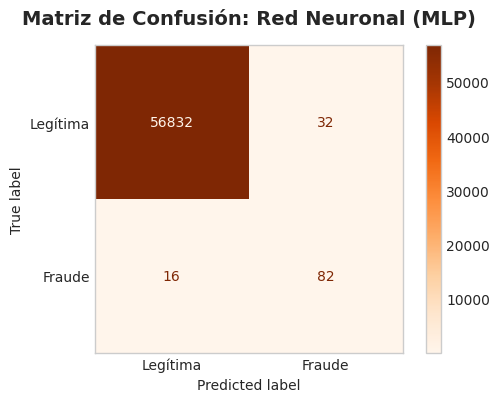

In [28]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)

X_test_scaled = scaler.transform(X_test)


mlp_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300, random_state=42)


mlp_model.fit(X_train_scaled, y_train_smote)



y_pred_mlp = mlp_model.predict(X_test_scaled)


print("MLP")

print(classification_report(y_test, y_pred_mlp, target_names=['Legítima (0)', 'Fraude (1)']))


fig, ax = plt.subplots(figsize=(6, 4))
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_mlp), display_labels=['Legítima', 'Fraude'])
disp.plot(cmap='Oranges', values_format='d', ax=ax)
plt.title('Matriz de Confusión: Red Neuronal (MLP)', fontsize=14, fontweight='bold', pad=15)
plt.grid(False)
plt.show()

In [27]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score


rus = RandomUnderSampler(random_state=42)
X_res_under, y_res_under = rus.fit_resample(X_train, y_train)
model_under = RandomForestClassifier(random_state=42, n_jobs=-1).fit(X_res_under, y_res_under)
recall_under = recall_score(y_test, model_under.predict(X_test))


model_cw = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced').fit(X_train, y_train)
recall_cw = recall_score(y_test, model_cw.predict(X_test))


print("comparación de tecnicas de balanceo")
print(f"1. SMOTE (Sobremuestreo): 0.83")
print(f"2. Undersampling (Submuestreo): {recall_under:.2f}")
print(f"3. Class Weights (Ajuste de pesos): {recall_cw:.2f}")

comparación de tecnicas de balanceo
1. SMOTE (Sobremuestreo): 0.83
2. Undersampling (Submuestreo): 0.91
3. Class Weights (Ajuste de pesos): 0.76


In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


- Procesando Undersampling...
- Procesando Class Weights...


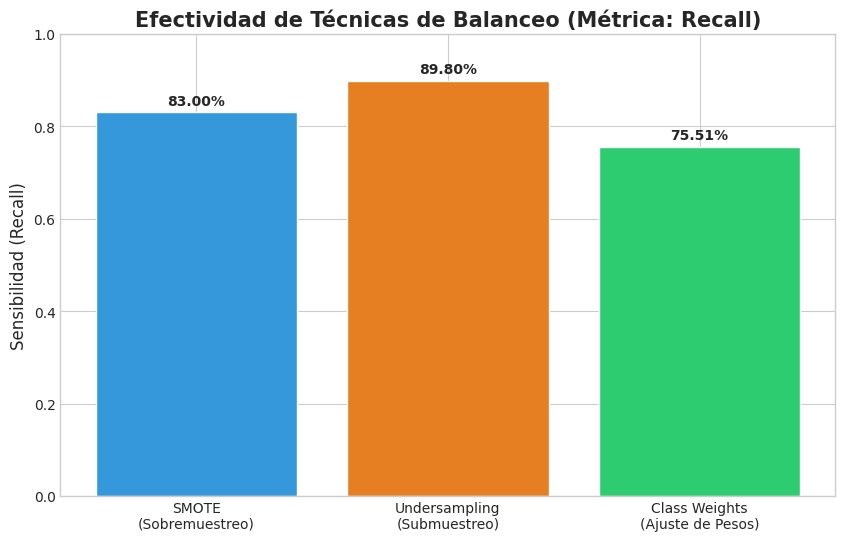

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score




print("- Procesando Undersampling...")
rus = RandomUnderSampler(random_state=42)
X_res_under, y_res_under = rus.fit_resample(X_train, y_train)
model_under = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=50).fit(X_res_under, y_res_under)
rec_under = recall_score(y_test, model_under.predict(X_test))


print("- Procesando Class Weights...")
model_cw = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=50, class_weight='balanced').fit(X_train, y_train)
rec_cw = recall_score(y_test, model_cw.predict(X_test))


rec_smote = 0.83


tecnicas = ['SMOTE\n(Sobremuestreo)', 'Undersampling\n(Submuestreo)', 'Class Weights\n(Ajuste de Pesos)']
valores = [rec_smote, rec_under, rec_cw]

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
bars = plt.bar(tecnicas, valores, color=['#3498db', '#e67e22', '#2ecc71'])


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2%}', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 1.0)
plt.title('Efectividad de Técnicas de Balanceo (Métrica: Recall)', fontsize=15, fontweight='bold')
plt.ylabel('Sensibilidad (Recall)', fontsize=12)
plt.show()

